In [1]:
using DataFrames, CSV, StatsPlots, StatsBase, Distributions, StatsFuns
include("measures.jl")

data = CSV.read("../../data/vitd/nhanes.csv", DataFrame);
println(first(data, 5))
println(size(data))

5×7 DataFrame
 Row │ BMXBMI   RIAGENDR  RIDAGEYR  LBXVIDMS  INDFMMPI  DPQ020   SMQ040  
     │ Float64  Float64   Float64   Float64   Float64   Float64  Float64 
─────┼───────────────────────────────────────────────────────────────────
   1 │    27.8       1.0      62.0      76.1      4.14      0.0      3.0
   2 │    30.8       1.0      53.0      56.5      0.0       0.0      1.0
   3 │    28.8       1.0      78.0      87.5      1.81      0.0      3.0
   4 │    28.0       1.0      22.0      47.2      2.98      0.0      2.0
   5 │    27.6       1.0      46.0      44.5      1.73      0.0      1.0
(1628, 7)


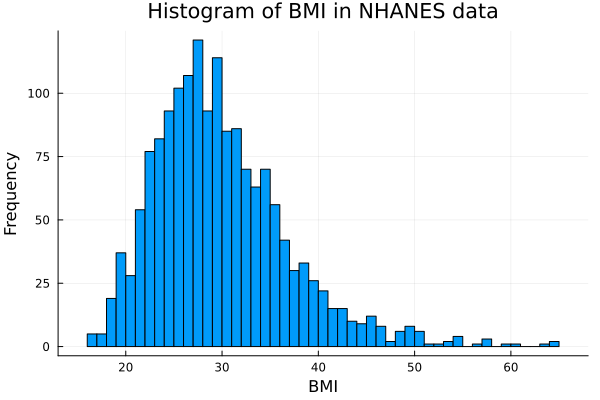

In [2]:
histogram(data."BMXBMI", bins=50, title="Histogram of BMI in NHANES data", xlabel="BMI", ylabel="Frequency", legend=false)

In [3]:
fit(LogNormal, data."BMXBMI")

LogNormal{Float64}(μ=3.371267719188432, σ=0.221631133482228)

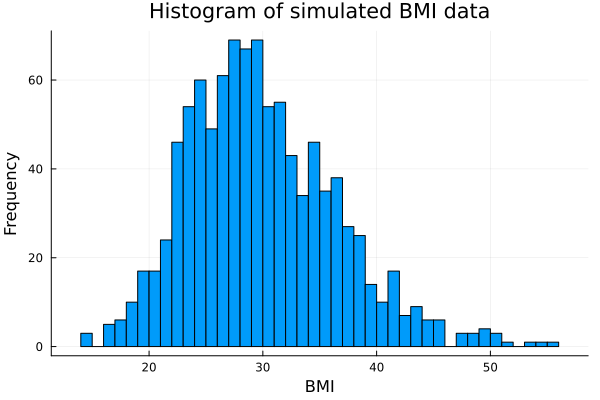

In [4]:
sample = LogNormal(3.37, 0.22)
histogram(rand(sample, 1000), bins=50, title="Histogram of simulated BMI data", xlabel="BMI", ylabel="Frequency", legend=false)

In [5]:
# gender

countmap(data."RIAGENDR")

Dict{Float64, Int64} with 2 entries:
  2.0 => 647
  1.0 => 981

In [6]:
639/(639+973)

0.3964019851116625

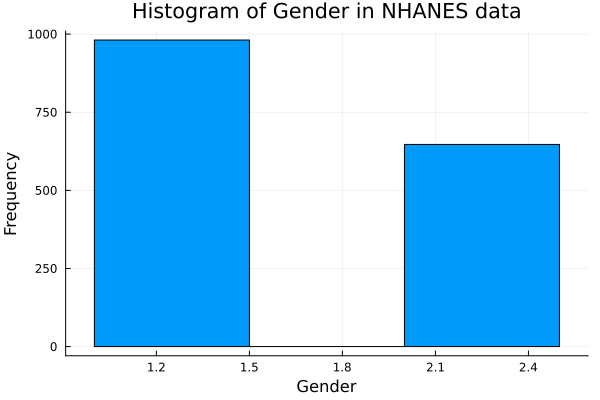

In [7]:
histogram(data."RIAGENDR", bins=2, title="Histogram of Gender in NHANES data", xlabel="Gender", ylabel="Frequency", legend=false)

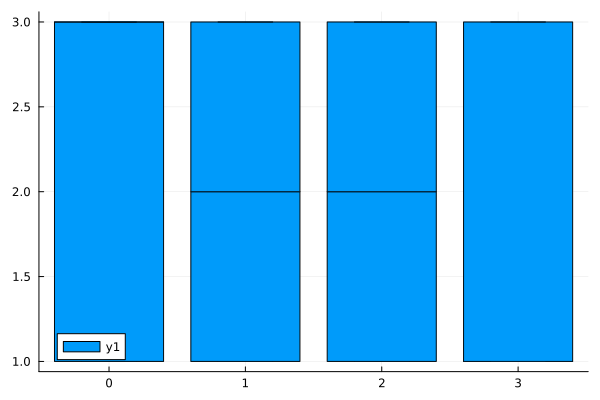

In [8]:
@df data boxplot(:DPQ020, :SMQ040)

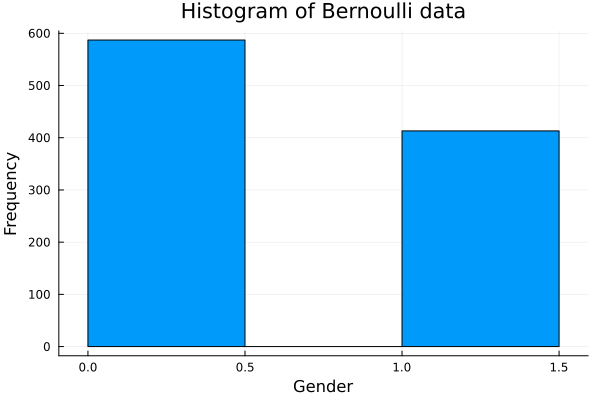

In [9]:
sample = Bernoulli(0.3964019851116625)
histogram(rand(sample, 1000), bins=2, title="Histogram of Bernoulli data" , xlabel="Gender", ylabel="Frequency", legend=false)

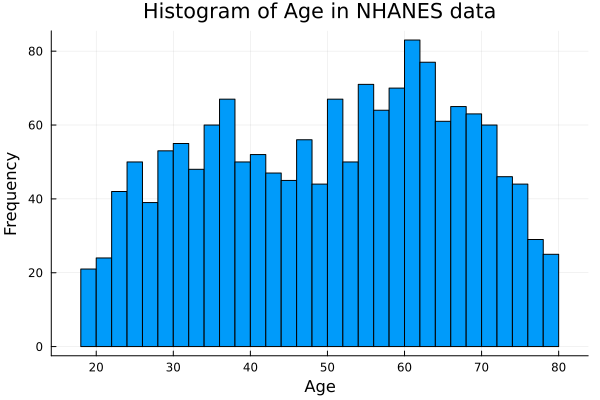

In [10]:
histogram(data."RIDAGEYR", bins=50, title="Histogram of Age in NHANES data", xlabel="Age", ylabel="Frequency", legend=false)

In [11]:
age_1 = filter(row -> row.RIDAGEYR <= 45, data)
age_2 = filter(row -> row.:RIDAGEYR > 45, data)

println(fit(Normal, age_1."RIDAGEYR"))
println(fit(Normal, age_2."RIDAGEYR"))

Normal{Float64}(μ=32.75344563552833, σ=7.295691395349148)
Normal{Float64}(μ=61.29435897435897, σ=8.770961352703825)


In [12]:
dist1 = Normal(32.7, 7.2)
dist2 = Normal(51.2, 8.7)
bimodal = MixtureModel([dist1, dist2], [0.4, 0.6])
bimodal

MixtureModel{Normal{Float64}}(K = 2)
components[1] (prior = 0.4000): Normal{Float64}(μ=32.7, σ=7.2)
components[2] (prior = 0.6000): Normal{Float64}(μ=51.2, σ=8.7)


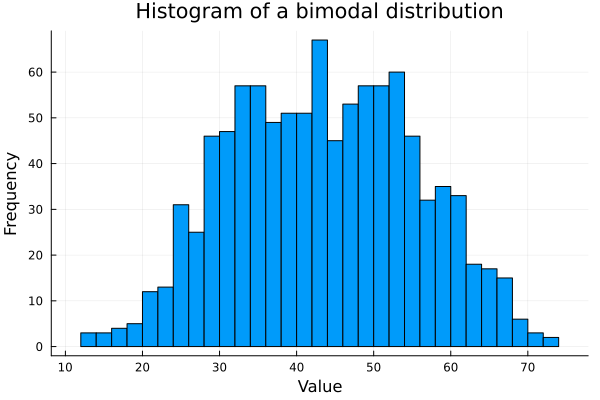

In [13]:
sample = rand(bimodal, 1000)
histogram(sample, bins=50, title="Histogram of a bimodal distribution", xlabel="Value", ylabel="Frequency", legend=false)

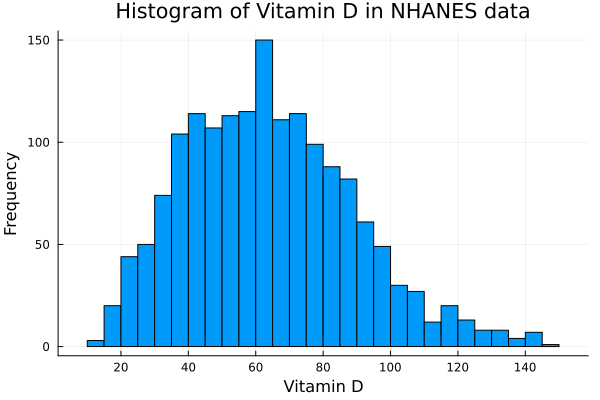

In [14]:
histogram(data."LBXVIDMS", bins=50, title="Histogram of Vitamin D in NHANES data", xlabel="Vitamin D", ylabel="Frequency", legend=false)

In [15]:
fit(LogNormal, data."LBXVIDMS")

LogNormal{Float64}(μ=4.0740204843877725, σ=0.4261816349414211)

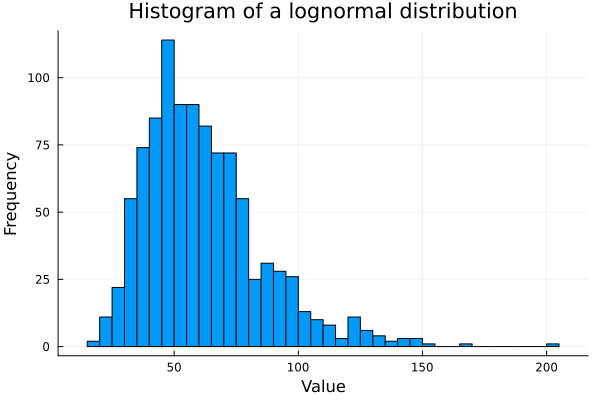

In [16]:
sample = rand(LogNormal(4.075, 0.37), 1000)
histogram(sample, bins=50, title="Histogram of a lognormal distribution", xlabel="Value", ylabel="Frequency", legend=false)

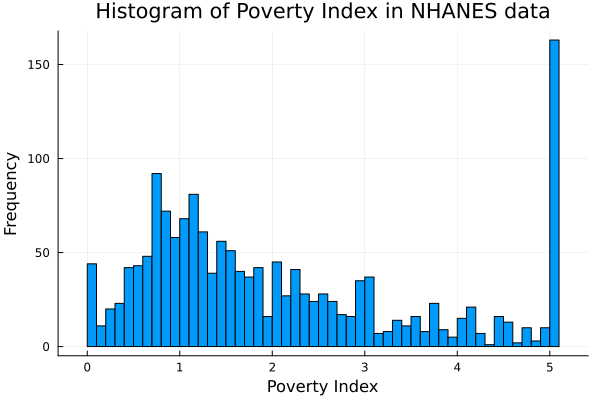

In [17]:
histogram(data."INDFMMPI", bins=50, title="Histogram of Poverty Index in NHANES data", xlabel="Poverty Index", ylabel="Frequency", legend=false)

In [18]:
dist1 = Normal(1, 2)
dist2 = Normal(5, 0.001)
bimodal = MixtureModel([dist1, dist2], [0.5, 0.5])


MixtureModel{Normal{Float64}}(K = 2)
components[1] (prior = 0.5000): Normal{Float64}(μ=1.0, σ=2.0)
components[2] (prior = 0.5000): Normal{Float64}(μ=5.0, σ=0.001)


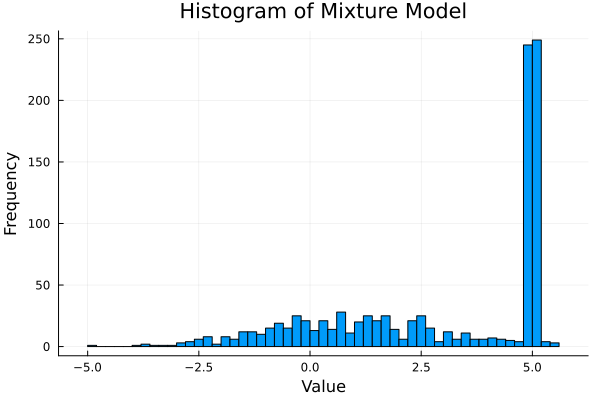

In [19]:
sample = rand(bimodal, 1000)
histogram(sample, bins=50, title="Histogram of Mixture Model", xlabel="Value", ylabel="Frequency", legend=false)

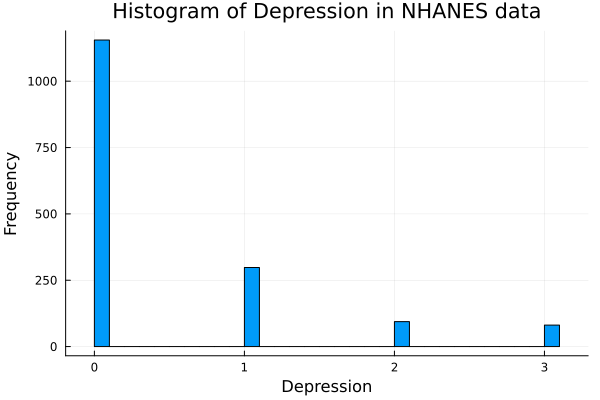

In [20]:
histogram(data."DPQ020", bins=50, title="Histogram of Depression in NHANES data", xlabel="Depression", ylabel="Frequency", legend=false)

In [21]:
countmap(data."DPQ020")

Dict{Float64, Int64} with 4 entries:
  0.0 => 1155
  2.0 => 94
  3.0 => 81
  1.0 => 298

In [22]:
total = 1143+94+78+296
println("Depression 0:", 1143/total, " Depression 1:", 296/total, " Depression 2:", 94/total, " Depression 3:", 78/total)

Depression 0:0.7094972067039106 Depression 1:0.18373680943513346 Depression 2:0.05834885164494103 Depression 3:0.048417132216014895


In [23]:
countmap(data."SMQ040")

Dict{Float64, Int64} with 3 entries:
  2.0 => 191
  3.0 => 857
  1.0 => 580

In [24]:
totalsmq = 574 + 850 + 188
println(574/totalsmq)
println(188/totalsmq)
println(850/totalsmq)

0.3560794044665012
0.11662531017369727
0.5272952853598015


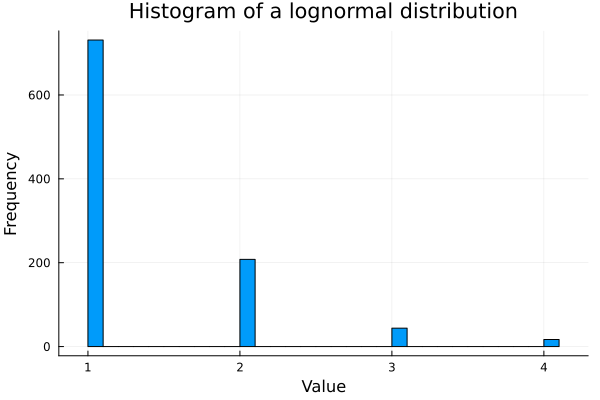

In [25]:
sample = rand(LogNormal(0.02, 0.6), 1000)
sample = clamp.(round.(Int, sample), 1, 4)
histogram(sample, bins=50, title="Histogram of a lognormal distribution", xlabel="Value", ylabel="Frequency", legend=false)

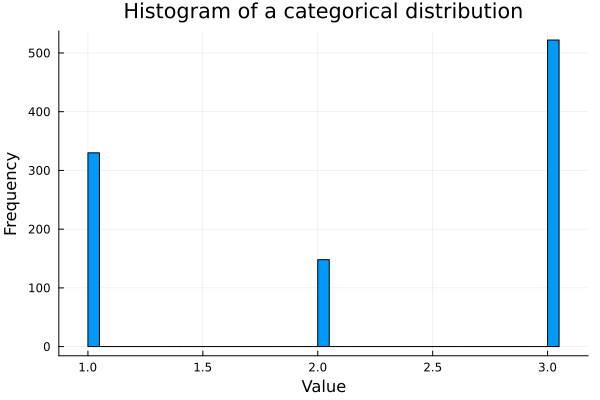

In [26]:
sample = rand(Categorical([0.35, 0.12, 0.53]), 1000)
histogram(sample, bins=50, title="Histogram of a categorical distribution", xlabel="Value", ylabel="Frequency", legend=false)

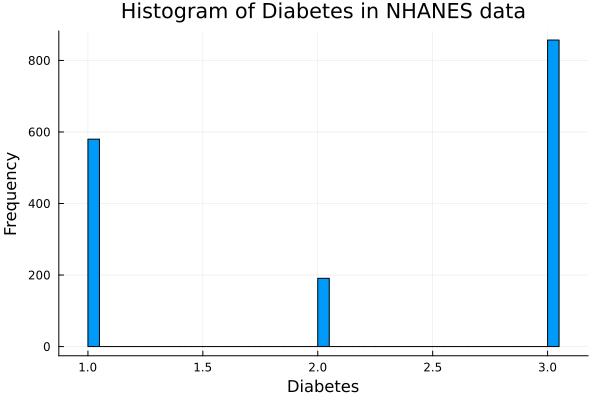

In [27]:
histogram(data."SMQ040", bins=50, title="Histogram of Diabetes in NHANES data", xlabel="Diabetes", ylabel="Frequency", legend=false)

In [28]:
logit2 = -0.12 + mean(data[!, "LBXVIDMS"]) * -0.0584824 + 0.123769 * mean(data[!, "RIDAGEYR"]) + -1.19336 * median(data[!, "RIAGENDR"]) + 1.27345 * median(data[!, "SMQ040"])
logit1 = logit2 - 0.5
logit3 = logit2 + 0.5 
logit4 = logit2 + 1

5.938592895233414

In [29]:
softmax([logit1, logit2, logit3, logit4])

4-element Vector{Float64}:
 0.1015363240915518
 0.16740509727844333
 0.27600434470659363
 0.45505423392341127

In [30]:
first(data,5)

Row,BMXBMI,RIAGENDR,RIDAGEYR,LBXVIDMS,INDFMMPI,DPQ020,SMQ040
,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,27.8,1.0,62.0,76.1,4.14,0.0,3.0
2,30.8,1.0,53.0,56.5,0.0,0.0,1.0
3,28.8,1.0,78.0,87.5,1.81,0.0,3.0
4,28.0,1.0,22.0,47.2,2.98,0.0,2.0
5,27.6,1.0,46.0,44.5,1.73,0.0,1.0


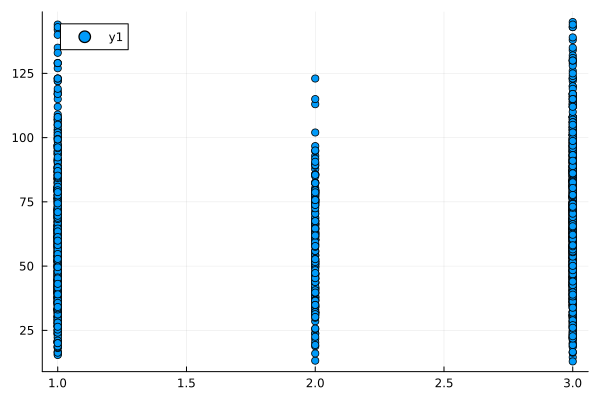

In [31]:
@df data scatter(:SMQ040, :LBXVIDMS)

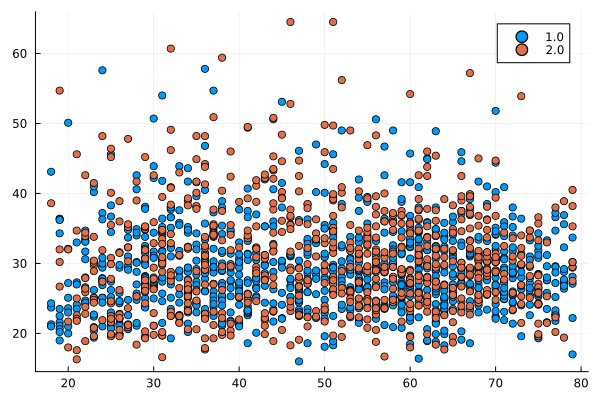

In [32]:
@df data scatter(:RIDAGEYR, :BMXBMI, group=:RIAGENDR)

In [33]:
cor(data."SMQ040", data."BMXBMI")

0.129533492668234

In [34]:
names(data)

7-element Vector{String}:
 "BMXBMI"
 "RIAGENDR"
 "RIDAGEYR"
 "LBXVIDMS"
 "INDFMMPI"
 "DPQ020"
 "SMQ040"

In [39]:
println("Means of the columns: bmi = ", mean(data."BMXBMI"), " age = ", mean(data."RIDAGEYR"), " vitamin d = ", mean(data."LBXVIDMS"), " poverty index = ", mean(data."INDFMMPI"))
println("Standard deviations of the columns: bmi = ", std(data."BMXBMI"), " age = ", std(data."RIDAGEYR"), " vitamin d = ", std(data."LBXVIDMS"), " poverty index = ", std(data."INDFMMPI"))
println("Medians of the columns: bmi = ", median(data."BMXBMI"), " age = ", median(data."RIDAGEYR"), " vitamin d = ", median(data."LBXVIDMS"), " poverty index = ", median(data."INDFMMPI"))
println("Maximum values of the columns: bmi = ", maximum(data."BMXBMI"), " age = ", maximum(data."RIDAGEYR"), " vitamin d = ", maximum(data."LBXVIDMS"), " poverty index = ", maximum(data."INDFMMPI"))
println("Minimum values of the columns: bmi = ", minimum(data."BMXBMI"), " age = ", minimum(data."RIDAGEYR"), " vitamin d = ", minimum(data."LBXVIDMS"), " poverty index = ", minimum(data."INDFMMPI"))

Means of the columns: bmi = 29.857371007371004 age = 49.84643734643735 vitamin d = 63.9139434889435 poverty index = 2.077739557739558
Standard deviations of the columns: bmi = 6.96504052531688 age = 16.22539476757406 vitamin d = 24.932510174538034 poverty index = 1.4766051201134396
Medians of the columns: bmi = 28.8 age = 51.0 vitamin d = 62.4 poverty index = 1.61
Maximum values of the columns: bmi = 64.5 age = 79.0 vitamin d = 145.0 poverty index = 5.0
Minimum values of the columns: bmi = 16.0 age = 18.0 vitamin d = 12.9 poverty index = 0.0


In [43]:
println("Value counts for the columns: gender = ", countmap(data."RIAGENDR"), "\ndepression = ", countmap(data."DPQ020"), "\nsmoking = ", countmap(data."SMQ040"))

Value counts for the columns: gender = Dict(2.0 => 647, 1.0 => 981)
depression = Dict(0.0 => 1155, 2.0 => 94, 3.0 => 81, 1.0 => 298)
smoking = Dict(2.0 => 191, 3.0 => 857, 1.0 => 580)


In [45]:
male_pop = 981/(981+647)
female_pop = 1-male_pop
println("Male population proportion $male_pop \n
        Female population proportion $female_pop")

Male population proportion 0.6025798525798526 

        Female population proportion 0.3974201474201474


In [49]:
non_smokers = 857/(981+647)
some_days = 191/(981+647)
smokers = 590/(981+647)
println("Non smokers proportion $non_smokers \n
        Some days smokers proportion $some_days \n
        Smokers proportion $smokers")

Non smokers proportion 0.5264127764127764 

        Some days smokers proportion 0.11732186732186732 

        Smokers proportion 0.36240786240786244


In [50]:
0.53 + 0.36 + 0.12

1.01

In [51]:
non_depressed = 1155/(981+647)
some_days = 298/(981+647)
more_than_half = 94/(981+647)
depressed = 81/(981+647)
println("Non depressed proportion $non_depressed \n
        Some days depressed proportion $some_days \n
        More than half days depressed proportion $more_than_half \n
        Depressed proportion $depressed")

Non depressed proportion 0.7094594594594594 

        Some days depressed proportion 0.18304668304668303 

        More than half days depressed proportion 0.05773955773955774 

        Depressed proportion 0.049754299754299756


In [52]:
0.71 + 0.18 + 0.06 + 0.05

1.0